# 04. Frozen Strategy Backtest

This notebook evaluates the pre-specified fixed-income strategy after all signal definitions and portfolio weights have been frozen.

The strategy is compared with two static monthly-rebalanced benchmarks:

- Equal Weight
- Core 60/40

Portfolio turnover is calculated using drift-adjusted pre-trade weights rather than simple target-weight differences.

The primary transaction-cost assumption remains fixed at 10 basis points per one-way turnover.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root  :", PROJECT_ROOT)
print("Processed dir :", PROCESSED_DIR)
print("Figures dir   :", FIGURES_DIR)

Project root  : c:\Users\minha\Desktop\global-fixed-income-strategy
Processed dir : c:\Users\minha\Desktop\global-fixed-income-strategy\data\processed
Figures dir   : c:\Users\minha\Desktop\global-fixed-income-strategy\figures


In [3]:
PORTFOLIO_DESIGN_PATH = (
    PROCESSED_DIR
    / "fixed_income_portfolio_design.csv"
)

portfolio_design = pd.read_csv(
    PORTFOLIO_DESIGN_PATH,
    index_col="Date",
    parse_dates=True,
)

portfolio_design.index.name = "Date"

print("Shape:", portfolio_design.shape)

print(
    "Date range:",
    portfolio_design.index.min(),
    "to",
    portfolio_design.index.max()
)

Shape: (223, 37)
Date range: 2008-01-31 00:00:00 to 2026-07-31 00:00:00


In [4]:
ETF_TICKERS = [
    "SHY",
    "IEF",
    "TLT",
    "LQD",
    "HYG",
]

WEIGHT_COLUMNS = [
    f"{ticker}_weight"
    for ticker in ETF_TICKERS
]

RETURN_COLUMNS = [
    f"{ticker}_ret"
    for ticker in ETF_TICKERS
]

BASE_TRANSACTION_COST_BPS = 10

BASE_TRANSACTION_COST = (
    BASE_TRANSACTION_COST_BPS
    / 10_000
)

BENCHMARK_WEIGHTS = {
    "Equal Weight": {
        "SHY": 0.20,
        "IEF": 0.20,
        "TLT": 0.20,
        "LQD": 0.20,
        "HYG": 0.20,
    },

    "Core 60/40": {
        "SHY": 0.00,
        "IEF": 0.60,
        "TLT": 0.00,
        "LQD": 0.40,
        "HYG": 0.00,
    },
}

In [5]:
strategy_start = (
    portfolio_design[
        WEIGHT_COLUMNS
    ]
    .dropna()
    .index.min()
)

backtest = (
    portfolio_design
    .loc[strategy_start:]
    .copy()
)

print("Strategy start :", strategy_start)
print("Backtest end   :", backtest.index.max())
print("Months         :", len(backtest))

Strategy start : 2008-05-31 00:00:00
Backtest end   : 2026-07-31 00:00:00
Months         : 219


In [6]:
assert (
    backtest[
        WEIGHT_COLUMNS
    ].notna().all().all()
)

assert (
    backtest[
        RETURN_COLUMNS
    ].notna().all().all()
)

assert np.allclose(
    backtest[
        WEIGHT_COLUMNS
    ].sum(axis=1),
    1.0
)

print(
    "Backtest input validation passed."
)

Backtest input validation passed.


## 1. Drift-Adjusted Backtest Accounting

Portfolio returns are calculated from beginning-of-month target weights.

At each month-end, asset-specific returns cause actual portfolio weights to drift away from their targets.

Before the next month's rebalance, turnover is therefore measured against the drifted portfolio rather than against the previous target weights:

\[
Turnover_t =
\frac{1}{2}
\sum_i
|w^{target}_{i,t} - w^{pretrade}_{i,t}|
\]

The first strategy allocation is treated as portfolio initialization and receives zero transaction cost.

In [7]:
def run_monthly_backtest(
    asset_returns,
    target_weights,
    transaction_cost=0.001,
):
    """
    Monthly portfolio backtest with drift-adjusted turnover.

    Parameters
    ----------
    asset_returns : DataFrame
        Monthly asset returns in decimal form.
    target_weights : DataFrame
        Beginning-of-month target portfolio weights.
    transaction_cost : float
        Cost per one-way turnover in decimal form.

    Returns
    -------
    DataFrame
        Gross/net returns, turnover, transaction cost,
        and portfolio wealth.
    """

    dates = target_weights.index

    records = []

    previous_end_weights = None

    for i, date in enumerate(dates):

        target = (
            target_weights
            .loc[date]
            .astype(float)
        )

        returns = (
            asset_returns
            .loc[date]
            .astype(float)
        )

        # First allocation is portfolio initialization.
        if previous_end_weights is None:
            turnover = 0.0

        else:
            turnover = (
                0.5
                * np.abs(
                    target
                    - previous_end_weights
                ).sum()
            )

        cost = (
            turnover
            * transaction_cost
        )

        gross_return = (
            target
            * returns
        ).sum()

        # Transaction cost is charged against beginning NAV.
        net_return = (
            gross_return
            - cost
        )

        end_values = (
            target
            * (1.0 + returns)
        )

        end_weights = (
            end_values
            / end_values.sum()
        )

        records.append({
            "Date": date,
            "Gross_Return": gross_return,
            "Turnover": turnover,
            "Transaction_Cost": cost,
            "Net_Return": net_return,
        })

        previous_end_weights = end_weights

    result = (
        pd.DataFrame(records)
        .set_index("Date")
    )

    result["Gross_Wealth"] = (
        1.0 + result["Gross_Return"]
    ).cumprod()

    result["Net_Wealth"] = (
        1.0 + result["Net_Return"]
    ).cumprod()

    return result

In [8]:
def run_monthly_backtest(
    asset_returns,
    target_weights,
    transaction_cost=0.001,
):
    """
    Monthly portfolio backtest with drift-adjusted turnover.

    Parameters
    ----------
    asset_returns : DataFrame
        Monthly asset returns in decimal form.
    target_weights : DataFrame
        Beginning-of-month target portfolio weights.
    transaction_cost : float
        Cost per one-way turnover in decimal form.

    Returns
    -------
    DataFrame
        Gross/net returns, turnover, transaction cost,
        and portfolio wealth.
    """

    dates = target_weights.index

    records = []

    previous_end_weights = None

    for i, date in enumerate(dates):

        target = (
            target_weights
            .loc[date]
            .astype(float)
        )

        returns = (
            asset_returns
            .loc[date]
            .astype(float)
        )

        # First allocation is portfolio initialization.
        if previous_end_weights is None:
            turnover = 0.0

        else:
            turnover = (
                0.5
                * np.abs(
                    target
                    - previous_end_weights
                ).sum()
            )

        cost = (
            turnover
            * transaction_cost
        )

        gross_return = (
            target
            * returns
        ).sum()

        # Transaction cost is charged against beginning NAV.
        net_return = (
            gross_return
            - cost
        )

        end_values = (
            target
            * (1.0 + returns)
        )

        end_weights = (
            end_values
            / end_values.sum()
        )

        records.append({
            "Date": date,
            "Gross_Return": gross_return,
            "Turnover": turnover,
            "Transaction_Cost": cost,
            "Net_Return": net_return,
        })

        previous_end_weights = end_weights

    result = (
        pd.DataFrame(records)
        .set_index("Date")
    )

    result["Gross_Wealth"] = (
        1.0 + result["Gross_Return"]
    ).cumprod()

    result["Net_Wealth"] = (
        1.0 + result["Net_Return"]
    ).cumprod()

    return result

In [11]:
strategy_returns = (
    backtest[
        RETURN_COLUMNS
    ]
    .copy()
)

strategy_returns.columns = ETF_TICKERS


strategy_weights = (
    backtest[
        WEIGHT_COLUMNS
    ]
    .copy()
)

strategy_weights.columns = ETF_TICKERS


print("Returns shape :", strategy_returns.shape)
print("Weights shape :", strategy_weights.shape)

print("\nReturn columns:")
print(strategy_returns.columns.tolist())

print("\nWeight columns:")
print(strategy_weights.columns.tolist())

Returns shape : (219, 5)
Weights shape : (219, 5)

Return columns:
['SHY', 'IEF', 'TLT', 'LQD', 'HYG']

Weight columns:
['SHY', 'IEF', 'TLT', 'LQD', 'HYG']


In [12]:
strategy_bt = run_monthly_backtest(
    asset_returns=strategy_returns,
    target_weights=strategy_weights,
    transaction_cost=BASE_TRANSACTION_COST,
)

strategy_bt.head()

,Gross_Return,Turnover,Transaction_Cost,Net_Return,Gross_Wealth,Net_Wealth
Date,,,,,,
2008-05-31,-0.010757,0.000000,0.000000,-0.010757,0.989243,0.989243
2008-06-30,-0.008647,0.302283,0.000302,-0.008949,0.980689,0.980390
2008-07-31,0.004952,0.006962,0.000007,0.004945,0.985545,0.985238
2008-08-31,0.006671,0.299876,0.000300,0.006371,0.992120,0.991515
2008-09-30,-0.015200,0.448903,0.000449,-0.015649,0.977039,0.975998


In [13]:
first_date = strategy_bt.index[0]

first_weights = (
    strategy_weights.loc[first_date]
)

first_returns = (
    strategy_returns.loc[first_date]
)

manual_gross_return = (
    first_weights
    * first_returns
).sum()

stored_gross_return = (
    strategy_bt.loc[
        first_date,
        "Gross_Return"
    ]
)

print("Date:", first_date)

print("\nStored gross return:")
print(stored_gross_return)

print("\nManual gross return:")
print(manual_gross_return)

print("\nTurnover:")
print(
    strategy_bt.loc[
        first_date,
        "Turnover"
    ]
)

print("\nTransaction cost:")
print(
    strategy_bt.loc[
        first_date,
        "Transaction_Cost"
    ]
)

assert np.isclose(
    stored_gross_return,
    manual_gross_return
)

assert np.isclose(
    strategy_bt.loc[
        first_date,
        "Turnover"
    ],
    0.0
)

assert np.isclose(
    strategy_bt.loc[
        first_date,
        "Transaction_Cost"
    ],
    0.0
)

print(
    "\nFirst-month accounting passed."
)

Date: 2008-05-31 00:00:00

Stored gross return:
-0.010757397577157725

Manual gross return:
-0.010757397577157725

Turnover:
0.0

Transaction cost:
0.0

First-month accounting passed.


In [14]:
date_1 = strategy_bt.index[0]
date_2 = strategy_bt.index[1]

w1 = strategy_weights.loc[date_1]
r1 = strategy_returns.loc[date_1]

gross_1 = (
    w1 * r1
).sum()

end_weights_1 = (
    w1 * (1.0 + r1)
) / (1.0 + gross_1)

target_2 = (
    strategy_weights.loc[date_2]
)

manual_turnover_2 = (
    0.5
    * np.abs(
        target_2
        - end_weights_1
    ).sum()
)

stored_turnover_2 = (
    strategy_bt.loc[
        date_2,
        "Turnover"
    ]
)

print("Previous month:", date_1)
print("Current month :", date_2)

print("\nEnd-of-previous-month drifted weights:")
print(end_weights_1)

print("\nCurrent target weights:")
print(target_2)

print("\nStored turnover:")
print(stored_turnover_2)

print("\nManual turnover:")
print(manual_turnover_2)

assert np.isclose(
    stored_turnover_2,
    manual_turnover_2
)

print(
    "\nDrift-adjusted turnover validation passed."
)

Previous month: 2008-05-31 00:00:00
Current month : 2008-06-30 00:00:00

End-of-previous-month drifted weights:
SHY    0.554057
IEF    0.248227
TLT    0.000000
LQD    0.197717
HYG    0.000000
Name: 2008-05-31 00:00:00, dtype: float64

Current target weights:
SHY    0.35
IEF    0.15
TLT    0.00
LQD    0.30
HYG    0.20
Name: 2008-06-30 00:00:00, dtype: float64

Stored turnover:
0.30228320373957995

Manual turnover:
0.30228320373957995

Drift-adjusted turnover validation passed.


In [15]:
check_date = strategy_bt.index[1]

manual_cost = (
    strategy_bt.loc[
        check_date,
        "Turnover"
    ]
    * BASE_TRANSACTION_COST
)

manual_net_return = (
    strategy_bt.loc[
        check_date,
        "Gross_Return"
    ]
    - manual_cost
)

print("Date:", check_date)

print("\nStored cost:")
print(
    strategy_bt.loc[
        check_date,
        "Transaction_Cost"
    ]
)

print("\nManual cost:")
print(manual_cost)

print("\nStored net return:")
print(
    strategy_bt.loc[
        check_date,
        "Net_Return"
    ]
)

print("\nManual net return:")
print(manual_net_return)

assert np.isclose(
    strategy_bt.loc[
        check_date,
        "Transaction_Cost"
    ],
    manual_cost
)

assert np.isclose(
    strategy_bt.loc[
        check_date,
        "Net_Return"
    ],
    manual_net_return
)

print(
    "\nTransaction-cost accounting passed."
)

Date: 2008-06-30 00:00:00

Stored cost:
0.00030228320373958

Manual cost:
0.00030228320373958

Stored net return:
-0.008948826215253175

Manual net return:
-0.008948826215253175

Transaction-cost accounting passed.


In [16]:
benchmark_weight_frames = {}

for benchmark_name, weights in BENCHMARK_WEIGHTS.items():

    benchmark_weights = pd.DataFrame(
        index=backtest.index,
        columns=ETF_TICKERS,
        dtype=float,
    )

    for ticker in ETF_TICKERS:
        benchmark_weights[ticker] = weights[ticker]

    benchmark_weight_frames[
        benchmark_name
    ] = benchmark_weights

print("Benchmark weight matrices created.")

for name, weights in benchmark_weight_frames.items():
    print(
        name,
        "->",
        weights.iloc[0].to_dict()
    )

Benchmark weight matrices created.
Equal Weight -> {'SHY': 0.2, 'IEF': 0.2, 'TLT': 0.2, 'LQD': 0.2, 'HYG': 0.2}
Core 60/40 -> {'SHY': 0.0, 'IEF': 0.6, 'TLT': 0.0, 'LQD': 0.4, 'HYG': 0.0}


In [17]:
benchmark_results = {}

for benchmark_name, benchmark_weights in (
    benchmark_weight_frames.items()
):

    benchmark_results[
        benchmark_name
    ] = run_monthly_backtest(
        asset_returns=strategy_returns,
        target_weights=benchmark_weights,
        transaction_cost=BASE_TRANSACTION_COST,
    )

print("Benchmark backtests complete.")

for name in benchmark_results:
    print("-", name)

Benchmark backtests complete.
- Equal Weight
- Core 60/40


In [18]:
print(
    "Regime Strategy:",
    strategy_bt.index.min(),
    "to",
    strategy_bt.index.max(),
    "| Months:",
    len(strategy_bt)
)

for name, result in benchmark_results.items():
    print(
        name + ":",
        result.index.min(),
        "to",
        result.index.max(),
        "| Months:",
        len(result)
    )

assert all(
    result.index.equals(strategy_bt.index)
    for result in benchmark_results.values()
)

print(
    "\nSample alignment validation passed."
)

Regime Strategy: 2008-05-31 00:00:00 to 2026-07-31 00:00:00 | Months: 219
Equal Weight: 2008-05-31 00:00:00 to 2026-07-31 00:00:00 | Months: 219
Core 60/40: 2008-05-31 00:00:00 to 2026-07-31 00:00:00 | Months: 219

Sample alignment validation passed.


## 3. Performance Evaluation

The frozen regime strategy and both static benchmarks are evaluated over the identical backtest period.

### Primary Metrics

- Sharpe ratio
- Maximum drawdown

### Secondary Metrics

- Total return
- CAGR
- Annualized return
- Annualized volatility
- Calmar ratio
- Average annual turnover

For the primary analysis, the Sharpe ratio uses a zero risk-free-rate convention for consistent cross-portfolio comparison.

In [19]:
def calculate_max_drawdown(returns):

    returns = returns.dropna()

    wealth = (
        1.0 + returns
    ).cumprod()

    running_peak = (
        wealth.cummax()
    )

    drawdown = (
        wealth
        / running_peak
        - 1.0
    )

    return drawdown.min()

In [20]:
def calculate_performance_metrics(
    returns,
    turnover=None,
):

    returns = returns.dropna()

    n_months = len(returns)
    years = n_months / 12

    total_return = (
        (1.0 + returns).prod()
        - 1.0
    )

    cagr = (
        (1.0 + total_return)
        ** (1.0 / years)
        - 1.0
    )

    annualized_return = (
        returns.mean()
        * 12
    )

    annualized_volatility = (
        returns.std(ddof=1)
        * np.sqrt(12)
    )

    if annualized_volatility > 0:

        sharpe = (
            annualized_return
            / annualized_volatility
        )

    else:
        sharpe = np.nan

    max_drawdown = (
        calculate_max_drawdown(
            returns
        )
    )

    if max_drawdown < 0:

        calmar = (
            cagr
            / abs(max_drawdown)
        )

    else:
        calmar = np.nan

    metrics = {
        "Total Return": total_return,
        "CAGR": cagr,
        "Ann. Return": annualized_return,
        "Ann. Volatility": annualized_volatility,
        "Sharpe (rf=0)": sharpe,
        "Max Drawdown": max_drawdown,
        "Calmar": calmar,
    }

    if turnover is not None:

        turnover = (
            turnover
            .reindex(returns.index)
            .fillna(0.0)
        )

        metrics[
            "Avg. Annual Turnover"
        ] = (
            turnover.mean()
            * 12
        )

    return metrics

In [21]:
performance_results = {}

performance_results[
    "Regime Strategy"
] = calculate_performance_metrics(
    returns=strategy_bt["Net_Return"],
    turnover=strategy_bt["Turnover"],
)

for benchmark_name, result in (
    benchmark_results.items()
):

    performance_results[
        benchmark_name
    ] = calculate_performance_metrics(
        returns=result["Net_Return"],
        turnover=result["Turnover"],
    )

performance_table = (
    pd.DataFrame(
        performance_results
    ).T
)

performance_table

,Total Return,CAGR,Ann. Return,Ann. Volatility,Sharpe (rf=0),Max Drawdown,Calmar,Avg. Annual Turnover
Regime Strategy,0.730540,0.030507,0.032226,0.065777,0.489933,-0.179519,0.169939,1.956141
Equal Weight,0.816810,0.033258,0.034793,0.064132,0.542521,-0.205525,0.161820,0.074072
Core 60/40,0.787177,0.032327,0.034082,0.067020,0.508541,-0.222470,0.145311,0.033947


In [22]:
display_table = (
    performance_table.copy()
)

percentage_columns = [
    "Total Return",
    "CAGR",
    "Ann. Return",
    "Ann. Volatility",
    "Max Drawdown",
    "Avg. Annual Turnover",
]

for col in percentage_columns:

    display_table[col] = (
        display_table[col]
        * 100
    )

display_table.round(2)

,Total Return,CAGR,Ann. Return,Ann. Volatility,Sharpe (rf=0),Max Drawdown,Calmar,Avg. Annual Turnover
Regime Strategy,73.05,3.05,3.22,6.58,0.49,-17.95,0.17,195.61
Equal Weight,81.68,3.33,3.48,6.41,0.54,-20.55,0.16,7.41
Core 60/40,78.72,3.23,3.41,6.70,0.51,-22.25,0.15,3.39


In [23]:
strategy_gross_metrics = (
    calculate_performance_metrics(
        returns=strategy_bt[
            "Gross_Return"
        ],
        turnover=strategy_bt[
            "Turnover"
        ],
    )
)

strategy_net_metrics = (
    calculate_performance_metrics(
        returns=strategy_bt[
            "Net_Return"
        ],
        turnover=strategy_bt[
            "Turnover"
        ],
    )
)

gross_net_table = pd.DataFrame({
    "Gross": strategy_gross_metrics,
    "Net": strategy_net_metrics,
}).T

gross_net_display = (
    gross_net_table.copy()
)

for col in percentage_columns:

    if col in gross_net_display.columns:

        gross_net_display[col] = (
            gross_net_display[col]
            * 100
        )

gross_net_display.round(3)

,Total Return,CAGR,Ann. Return,Ann. Volatility,Sharpe (rf=0),Max Drawdown,Calmar,Avg. Annual Turnover
Gross,79.329,3.252,3.418,6.577,0.52,-17.550,0.185,195.614
Net,73.054,3.051,3.223,6.578,0.49,-17.952,0.170,195.614


In [24]:
total_transaction_cost = (
    strategy_bt[
        "Transaction_Cost"
    ].sum()
)

average_monthly_turnover = (
    strategy_bt[
        "Turnover"
    ].mean()
)

annualized_turnover = (
    average_monthly_turnover
    * 12
)

months_with_rebalancing = (
    strategy_bt[
        "Turnover"
    ]
    .gt(0)
    .sum()
)

print(
    "Summed transaction-cost fraction:",
    total_transaction_cost
)

print(
    "Average monthly turnover:",
    average_monthly_turnover
)

print(
    "Annualized turnover:",
    annualized_turnover
)

print(
    "Months with non-zero turnover:",
    months_with_rebalancing,
    "/",
    len(strategy_bt)
)

print(
    "\nGross CAGR:",
    strategy_gross_metrics["CAGR"]
)

print(
    "Net CAGR:",
    strategy_net_metrics["CAGR"]
)

print(
    "CAGR drag:",
    strategy_gross_metrics["CAGR"]
    - strategy_net_metrics["CAGR"]
)

Summed transaction-cost fraction: 0.03569956467321911
Average monthly turnover: 0.16301171083661692
Annualized turnover: 1.956140530039403
Months with non-zero turnover: 218 / 219

Gross CAGR: 0.03252058818367365
Net CAGR: 0.030507249659534885
CAGR drag: 0.0020133385241387636


In [25]:
wealth_panel = pd.DataFrame(
    index=strategy_bt.index
)

wealth_panel[
    "Regime Strategy"
] = strategy_bt[
    "Net_Wealth"
]

for benchmark_name, result in (
    benchmark_results.items()
):

    wealth_panel[
        benchmark_name
    ] = result[
        "Net_Wealth"
    ]

wealth_panel.tail()

,Regime Strategy,Equal Weight,Core 60/40
Date,,,
2026-03-31,1.739052,1.829962,1.808658
2026-04-30,1.740425,1.833625,1.809065
2026-05-31,1.744076,1.840550,1.815097
2026-06-30,1.745498,1.846735,1.818649
2026-07-31,1.730540,1.816810,1.787177


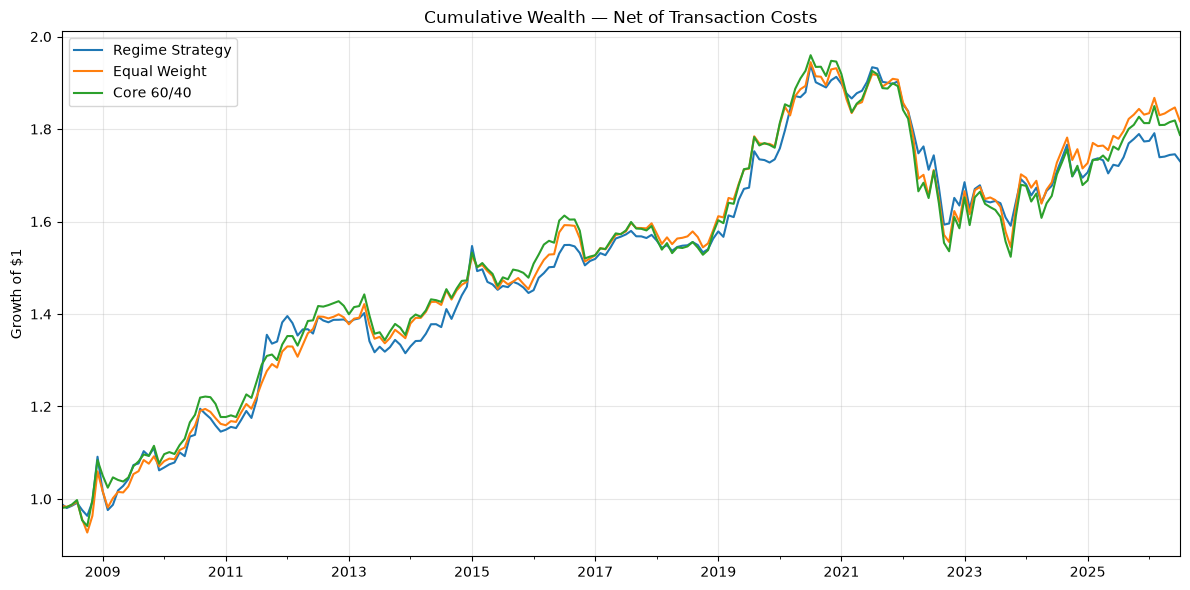

In [26]:
fig, ax = plt.subplots(
    figsize=(12, 6)
)

wealth_panel.plot(ax=ax)

ax.set_title(
    "Cumulative Wealth — Net of Transaction Costs"
)

ax.set_xlabel("")
ax.set_ylabel(
    "Growth of $1"
)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
def calculate_drawdown_series(
    returns
):

    returns = returns.dropna()

    wealth = (
        1.0 + returns
    ).cumprod()

    peak = (
        wealth.cummax()
    )

    return (
        wealth
        / peak
        - 1.0
    )

In [28]:
drawdown_panel = pd.DataFrame(
    index=strategy_bt.index
)

drawdown_panel[
    "Regime Strategy"
] = calculate_drawdown_series(
    strategy_bt[
        "Net_Return"
    ]
)

for benchmark_name, result in (
    benchmark_results.items()
):

    drawdown_panel[
        benchmark_name
    ] = calculate_drawdown_series(
        result[
            "Net_Return"
        ]
    )

print("Maximum Drawdowns:")

drawdown_panel.min()

Maximum Drawdowns:


Regime Strategy   -0.179519
Equal Weight      -0.205525
Core 60/40        -0.222470
dtype: float64

In [29]:
for portfolio_name in (
    performance_table.index
):

    expected_mdd = (
        performance_table.loc[
            portfolio_name,
            "Max Drawdown"
        ]
    )

    actual_mdd = (
        drawdown_panel[
            portfolio_name
        ].min()
    )

    assert np.isclose(
        expected_mdd,
        actual_mdd
    )

print(
    "Maximum-drawdown validation passed."
)

Maximum-drawdown validation passed.


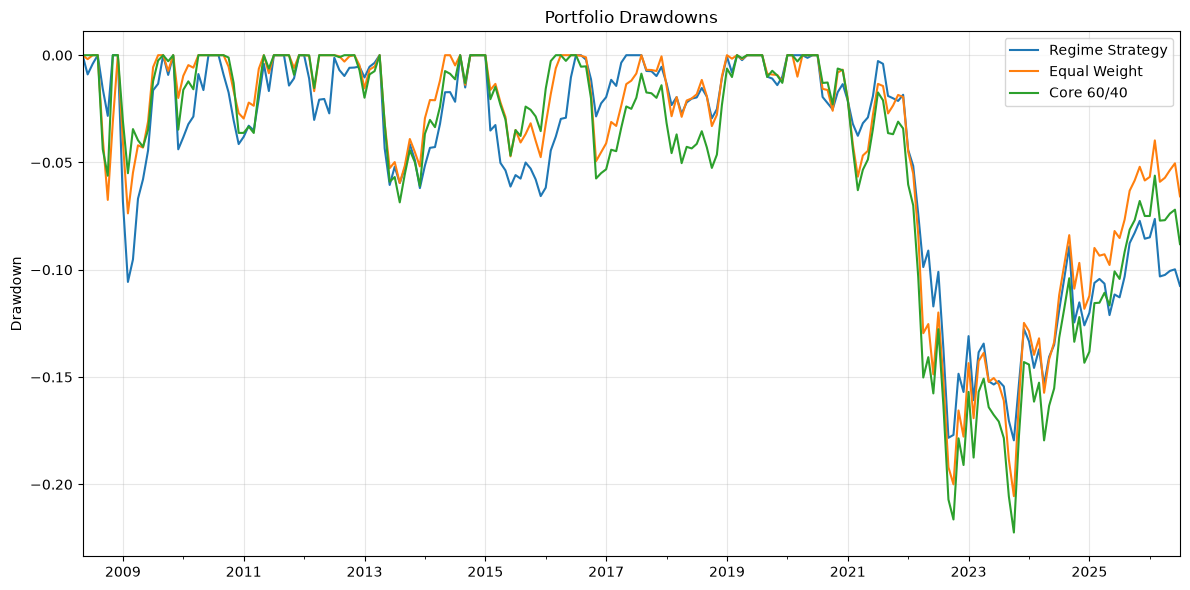

In [30]:
fig, ax = plt.subplots(
    figsize=(12, 6)
)

drawdown_panel.plot(ax=ax)

ax.set_title(
    "Portfolio Drawdowns"
)

ax.set_xlabel("")
ax.set_ylabel(
    "Drawdown"
)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Pre-Defined Stress-Period Analysis

The frozen portfolios are evaluated across three well-known fixed-income stress environments:

- Global Financial Crisis
- COVID-19 shock
- 2022 rate-hiking shock

These periods are used only for descriptive analysis and do not affect strategy rules.

In [31]:
STRESS_PERIODS = {
    "Global Financial Crisis": (
        "2008-05-31",
        "2009-06-30",
    ),

    "COVID Shock": (
        "2020-02-29",
        "2020-05-31",
    ),

    "2022 Rate Shock": (
        "2022-01-31",
        "2022-12-31",
    ),
}

STRESS_PERIODS

{'Global Financial Crisis': ('2008-05-31', '2009-06-30'),
 'COVID Shock': ('2020-02-29', '2020-05-31'),
 '2022 Rate Shock': ('2022-01-31', '2022-12-31')}

In [32]:
net_return_panel = pd.DataFrame(
    index=strategy_bt.index
)

net_return_panel[
    "Regime Strategy"
] = strategy_bt[
    "Net_Return"
]

for benchmark_name, result in (
    benchmark_results.items()
):

    net_return_panel[
        benchmark_name
    ] = result[
        "Net_Return"
    ]

net_return_panel.head()

,Regime Strategy,Equal Weight,Core 60/40
Date,,,
2008-05-31,-0.010757,-0.015051,-0.019485
2008-06-30,-0.008949,-0.001847,0.001708
2008-07-31,0.004945,0.003527,0.005879
2008-08-31,0.006371,0.007957,0.009738
2008-09-30,-0.015649,-0.038551,-0.043767


In [33]:
stress_results = []

for period_name, (
    start,
    end,
) in STRESS_PERIODS.items():

    period_returns = (
        net_return_panel.loc[
            start:end
        ]
    )

    for portfolio_name in (
        period_returns.columns
    ):

        cumulative_return = (
            (
                1.0
                + period_returns[
                    portfolio_name
                ]
            ).prod()
            - 1.0
        )

        max_drawdown = (
            calculate_max_drawdown(
                period_returns[
                    portfolio_name
                ]
            )
        )

        stress_results.append({
            "Period": period_name,
            "Portfolio": portfolio_name,
            "Cumulative_Return":
                cumulative_return,
            "Max_Drawdown":
                max_drawdown,
        })

stress_table = pd.DataFrame(
    stress_results
)

stress_table

,Period,Portfolio,Cumulative_Return,Max_Drawdown
0,Global Financial Crisis,Regime Strategy,0.042817,-0.105665
1,Global Financial Crisis,Equal Weight,0.026903,-0.073722
2,Global Financial Crisis,Core 60/40,0.046219,-0.056168
3,COVID Shock,Regime Strategy,0.062978,-0.001230
4,COVID Shock,Equal Weight,0.041552,-0.010003
5,COVID Shock,Core 60/40,0.052839,-0.002916
6,2022 Rate Shock,Regime Strategy,-0.141138,-0.140376
7,2022 Rate Shock,Equal Weight,-0.161406,-0.162388
8,2022 Rate Shock,Core 60/40,-0.162399,-0.166126


In [34]:
stress_display = (
    stress_table.copy()
)

stress_display[
    "Cumulative_Return"
] *= 100

stress_display[
    "Max_Drawdown"
] *= 100

stress_display.round(2)

,Period,Portfolio,Cumulative_Return,Max_Drawdown
0,Global Financial Crisis,Regime Strategy,4.28,-10.57
1,Global Financial Crisis,Equal Weight,2.69,-7.37
2,Global Financial Crisis,Core 60/40,4.62,-5.62
3,COVID Shock,Regime Strategy,6.30,-0.12
4,COVID Shock,Equal Weight,4.16,-1.00
5,COVID Shock,Core 60/40,5.28,-0.29
6,2022 Rate Shock,Regime Strategy,-14.11,-14.04
7,2022 Rate Shock,Equal Weight,-16.14,-16.24
8,2022 Rate Shock,Core 60/40,-16.24,-16.61


In [35]:
annual_returns = (
    (1.0 + net_return_panel)
    .resample("YE")
    .prod()
    - 1.0
)

annual_returns.index = (
    annual_returns.index.year
)

annual_returns

,Regime Strategy,Equal Weight,Core 60/40
Date,,,
2008,0.091291,0.059682,0.083995
2009,-0.026987,0.010238,-0.007160
2010,0.078893,0.085842,0.093808
2011,0.206237,0.134498,0.133195
2012,0.004586,0.056146,0.062809
2013,-0.052581,-0.032398,-0.044641
2014,0.109391,0.090642,0.087265
2015,-0.009332,-0.010941,0.003990
2016,0.047870,0.045651,0.030868


In [36]:
annual_summary = []

for portfolio_name in (
    annual_returns.columns
):

    series = (
        annual_returns[
            portfolio_name
        ]
    )

    annual_summary.append({
        "Portfolio":
            portfolio_name,

        "Best_Year":
            series.idxmax(),

        "Best_Return":
            series.max(),

        "Worst_Year":
            series.idxmin(),

        "Worst_Return":
            series.min(),

        "Positive_Years":
            (series > 0).sum(),

        "Negative_Years":
            (series < 0).sum(),
    })

annual_summary = pd.DataFrame(
    annual_summary
)

annual_summary

,Portfolio,Best_Year,Best_Return,Worst_Year,Worst_Return,Positive_Years,Negative_Years
0,Regime Strategy,2011,0.206237,2022,-0.141138,12,7
1,Equal Weight,2011,0.134498,2022,-0.161406,13,6
2,Core 60/40,2011,0.133195,2022,-0.162399,12,7


In [37]:
assert (
    strategy_bt.index.min()
    == pd.Timestamp(
        "2008-05-31"
    )
)

assert (
    strategy_bt.index.max()
    == pd.Timestamp(
        "2026-07-31"
    )
)

assert (
    strategy_bt[
        [
            "Gross_Return",
            "Turnover",
            "Transaction_Cost",
            "Net_Return",
        ]
    ]
    .notna()
    .all()
    .all()
)

assert (
    strategy_bt[
        "Turnover"
    ].ge(0).all()
)

assert (
    strategy_bt[
        "Transaction_Cost"
    ].ge(0).all()
)

assert (
    strategy_bt[
        "Net_Return"
    ]
    <= strategy_bt[
        "Gross_Return"
    ] + 1e-12
).all()

print("=" * 60)

print(
    "STEP 5 — FROZEN STRATEGY BACKTEST COMPLETE"
)

print("=" * 60)

print(
    "\nBacktest period:",
    strategy_bt.index.min().date(),
    "→",
    strategy_bt.index.max().date()
)

print(
    "\nObservations:",
    len(strategy_bt)
)

print(
    "\nTransaction cost:",
    f"{BASE_TRANSACTION_COST_BPS} bps"
)

print(
    "\nSignal definitions remained frozen."
)

print(
    "Portfolio weights remained frozen."
)

print(
    "No parameter was modified after observing performance."
)

STEP 5 — FROZEN STRATEGY BACKTEST COMPLETE

Backtest period: 2008-05-31 → 2026-07-31

Observations: 219

Transaction cost: 10 bps

Signal definitions remained frozen.
Portfolio weights remained frozen.
No parameter was modified after observing performance.


In [38]:
BACKTEST_PATH = (
    PROCESSED_DIR
    / "fixed_income_backtest_results.csv"
)

PERFORMANCE_PATH = (
    PROCESSED_DIR
    / "fixed_income_performance_summary.csv"
)

STRESS_PATH = (
    PROCESSED_DIR
    / "fixed_income_stress_summary.csv"
)

strategy_bt.to_csv(
    BACKTEST_PATH
)

performance_table.to_csv(
    PERFORMANCE_PATH
)

stress_table.to_csv(
    STRESS_PATH,
    index=False
)

print(
    "Backtest results:",
    BACKTEST_PATH.exists()
)

print(
    "Performance summary:",
    PERFORMANCE_PATH.exists()
)

print(
    "Stress summary:",
    STRESS_PATH.exists()
)

Backtest results: True
Performance summary: True
Stress summary: True


## Step 5 Conclusion

The frozen regime strategy has now been evaluated without modifying any signal or allocation parameter.

The backtest uses:

- pre-specified three-month rate and credit signals,
- pre-specified regime classifications,
- frozen portfolio weights,
- previous-month information only,
- drift-adjusted turnover,
- identical evaluation periods across portfolios,
- and a 10-basis-point transaction-cost assumption.

Subsequent analysis focuses on explaining portfolio risk, stress sensitivity, and performance attribution rather than improving the historical backtest.